In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score


In [2]:
#credit = fetch_openml(name='credit-g', version=2, as_frame=True)

#df = credit.frame
df = pd.read_csv('credit_g.csv')
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


===== VISÃO GERAL DO DATASET =====
Número de instâncias: 1000
Número total de atributos (incluindo classe): 21

===== TIPOS DE ATRIBUTOS =====
Número de atributos numéricos: 7
Número de atributos categóricos: 14

===== DISTRIBUIÇÃO DA CLASSE =====
class
good    700
bad     300
Name: count, dtype: int64



/tmp/ipykernel_21814/941552263.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


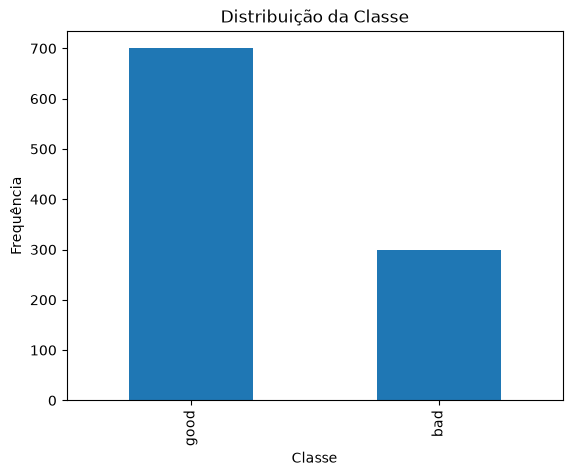

In [3]:
# ==============================
# Análise Exploratória Básica
# ==============================

import matplotlib.pyplot as plt

print("===== VISÃO GERAL DO DATASET =====")
print(f"Número de instâncias: {df.shape[0]}")
print(f"Número total de atributos (incluindo classe): {df.shape[1]}")
print()

# Separando tipos de atributos
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("===== TIPOS DE ATRIBUTOS =====")
print(f"Número de atributos numéricos: {len(numeric_cols)}")
print(f"Número de atributos categóricos: {len(categorical_cols)}")
print()

# ==============================
# Distribuição da classe
# ==============================
print("===== DISTRIBUIÇÃO DA CLASSE =====")
print(df['class'].value_counts())
print()

plt.figure()
df['class'].value_counts().plot(kind='bar')
plt.title("Distribuição da Classe")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.show()

===== DISTRIBUIÇÃO DOS ATRIBUTOS CATEGÓRICOS =====

Atributo: checking_status
checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64


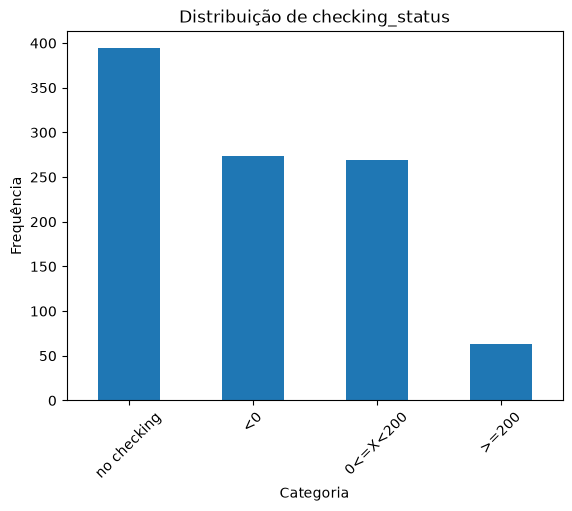


Atributo: credit_history
credit_history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64


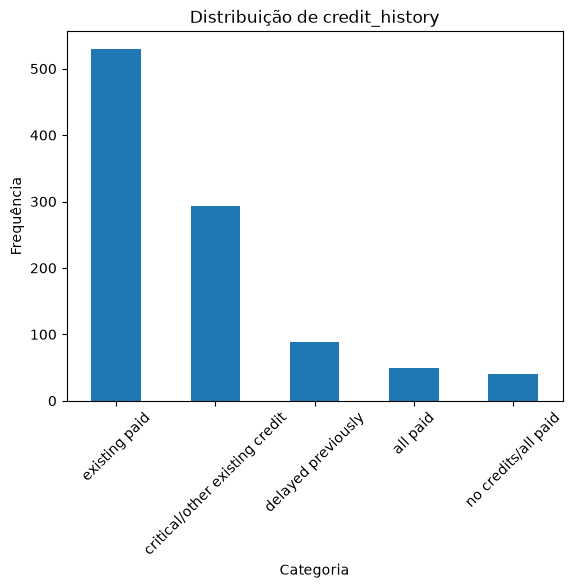


Atributo: purpose
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64


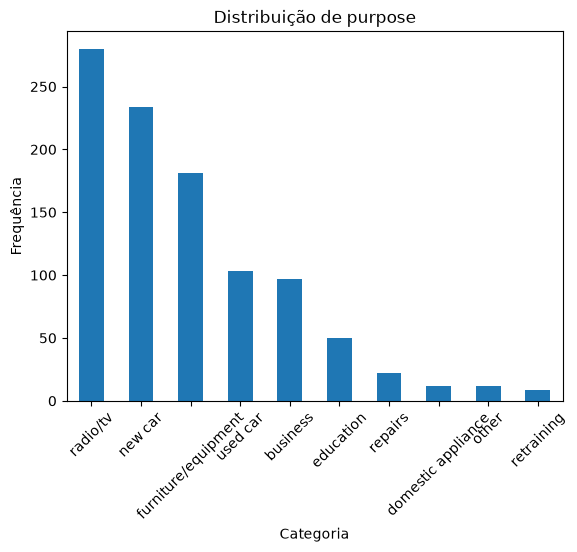


Atributo: savings_status
savings_status
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64


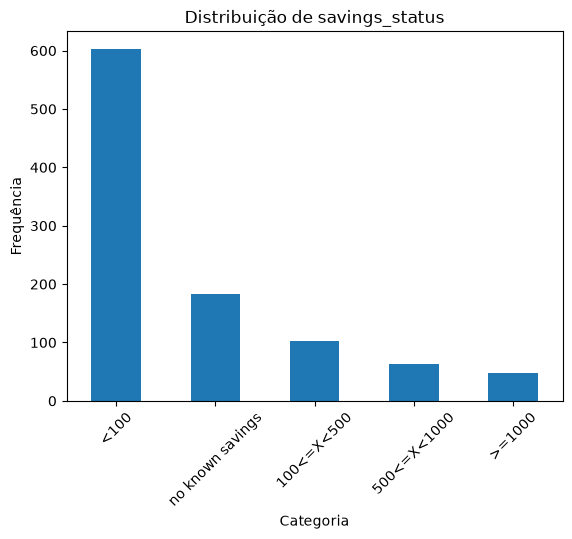


Atributo: employment
employment
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: count, dtype: int64


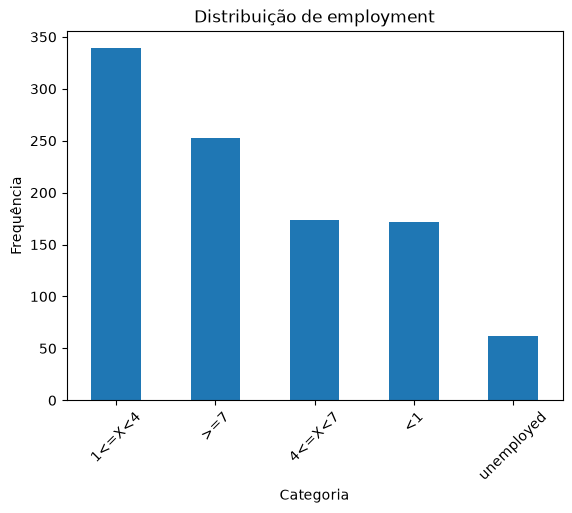


Atributo: personal_status
personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64


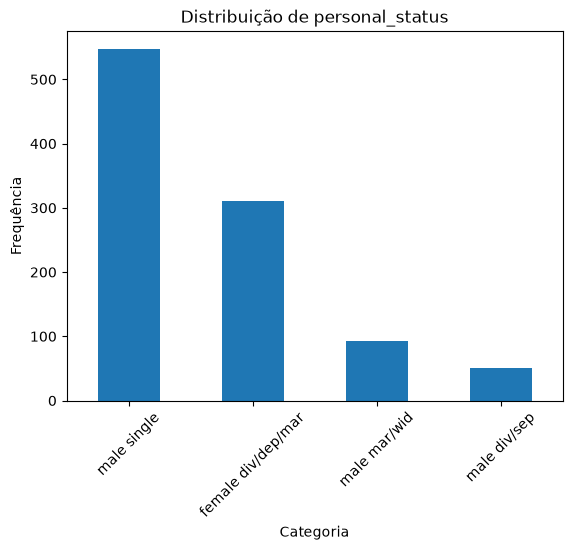


Atributo: other_parties
other_parties
none            907
guarantor        52
co applicant     41
Name: count, dtype: int64


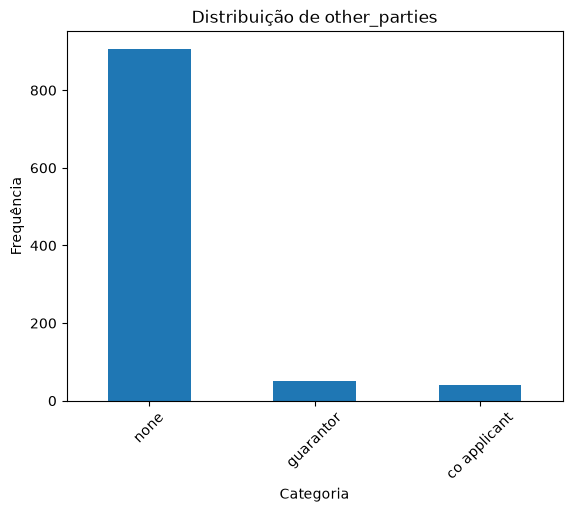


Atributo: property_magnitude
property_magnitude
car                  332
real estate          282
life insurance       232
no known property    154
Name: count, dtype: int64


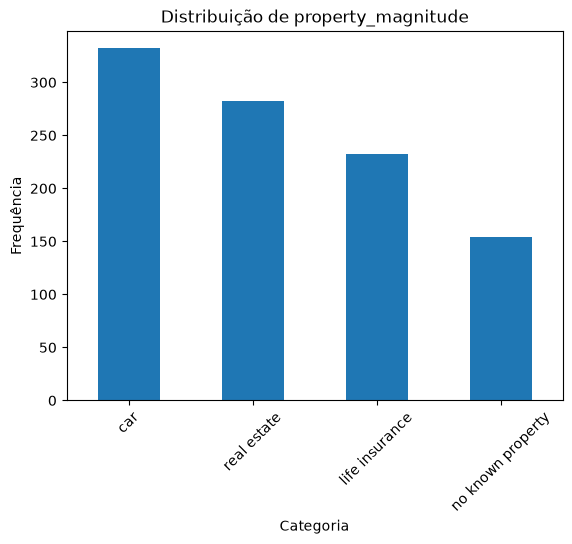


Atributo: other_payment_plans
other_payment_plans
none      814
bank      139
stores     47
Name: count, dtype: int64


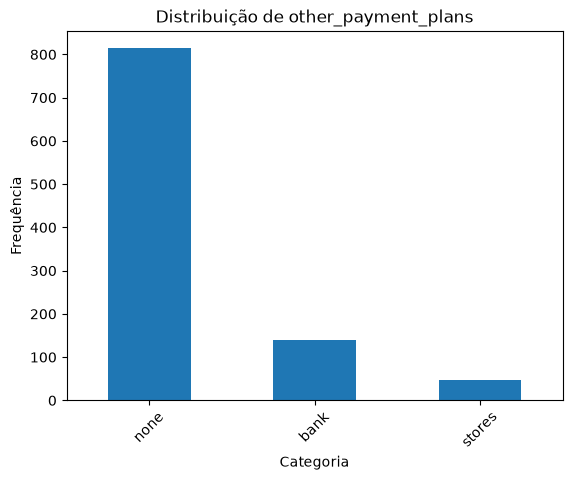


Atributo: housing
housing
own         713
rent        179
for free    108
Name: count, dtype: int64


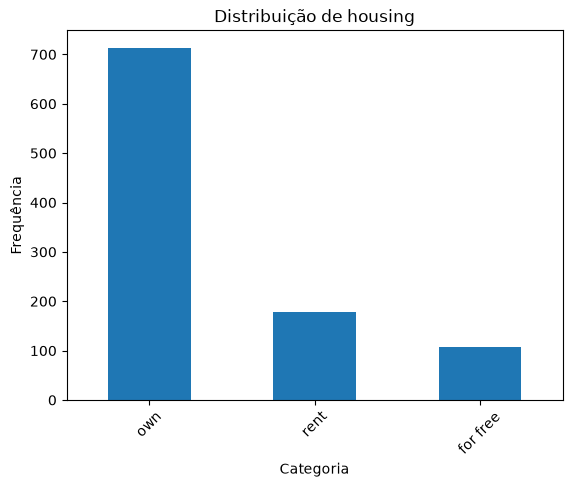


Atributo: job
job
skilled                      630
unskilled resident           200
high qualif/self emp/mgmt    148
unemp/unskilled non res       22
Name: count, dtype: int64


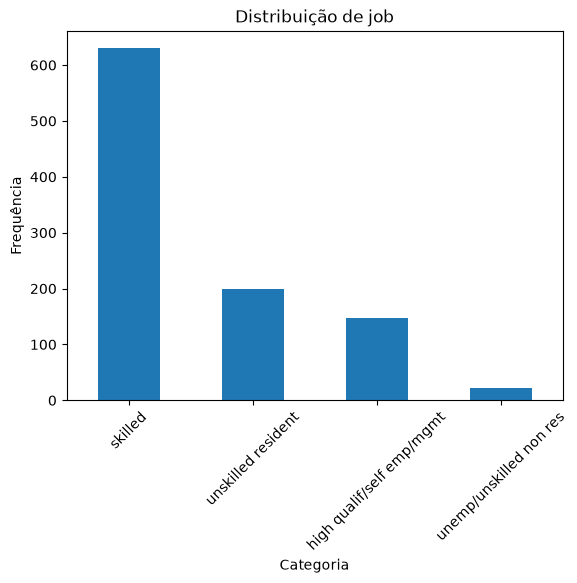


Atributo: own_telephone
own_telephone
none    596
yes     404
Name: count, dtype: int64


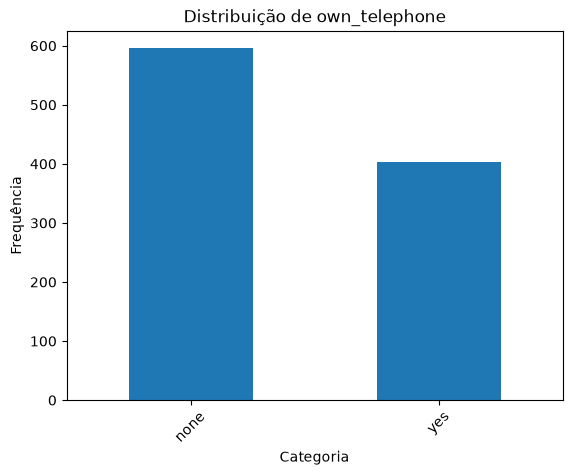


Atributo: foreign_worker
foreign_worker
yes    963
no      37
Name: count, dtype: int64


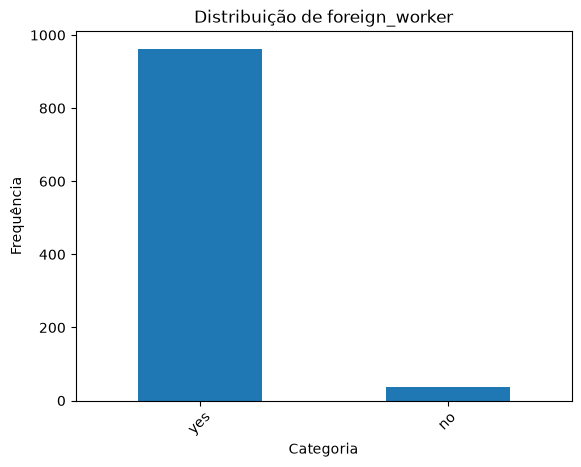


Atributo: class
class
good    700
bad     300
Name: count, dtype: int64


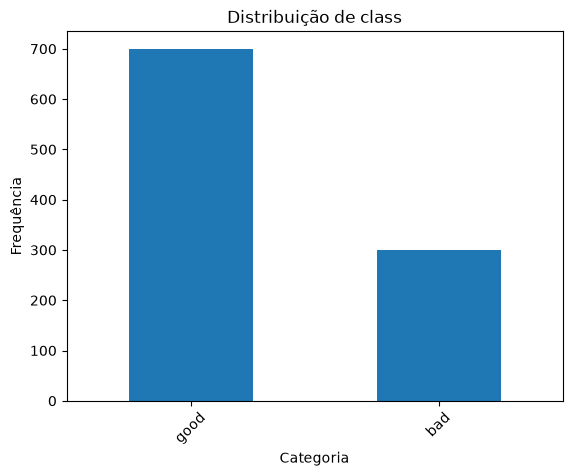

In [4]:
# ==============================
# Distribuição categórica (com gráficos)
# ==============================
print("===== DISTRIBUIÇÃO DOS ATRIBUTOS CATEGÓRICOS =====")

for col in categorical_cols:
    print(f"\nAtributo: {col}")
    print(df[col].value_counts())

    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribuição de {col}")
    plt.xlabel("Categoria")
    plt.ylabel("Frequência")
    plt.xticks(rotation=45)
    plt.show()

In [5]:
# Separando X (entradas) e y (saídas) para se adequar às funções do scikit-learn.
X = df.drop(columns=['class'])
y = df['class']

# Faz uma divisão dos dados: reserva 20% e deixa fora do treinamento do modelo.
# Este conjunto simula novos dados (nunca antes vistos) e são chamados de Dados de Teste.
# O restante dos dados (80%) é usado para treinamento do modelo.
# Garantimos fazer UM ÚNICO split para todos os experimentos - garante comparações corretas e justas.
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamanho treino:", X_train_full.shape)
print("Tamanho teste:", X_test_full.shape)

Tamanho treino: (800, 20)
Tamanho teste: (200, 20)


In [6]:
# Identificando colunas numéricas
numeric_cols = X_train_full.select_dtypes(include=['int64', 'float64']).columns

# Aplicando a seleção ao treino e teste
X_train_num = X_train_full[numeric_cols]
X_test_num  = X_test_full[numeric_cols]

X_train_num.head()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
675,30,4530,4,4,26,1,1
703,30,2503,4,2,41,2,1
12,12,1567,1,1,22,1,1
845,21,3976,2,3,35,1,1
795,9,2301,2,4,22,1,1


In [7]:
# ==============================
# Treinando o modelo KNN (sem normalização)
# ==============================

# Criamos um objeto do classificador KNN.
# n_neighbors=3 significa que o modelo irá considerar os 3 vizinhos mais próximos
# para decidir a classe de uma nova instância.
#
# metric="euclidean" define que a distância utilizada será a distância euclidiana.
# Ou seja, o modelo irá medir proximidade no espaço geométrico dos atributos.

modelo = KNeighborsClassifier(n_neighbors=3, metric="euclidean")


# O método .fit() no KNN NÃO constrói um modelo paramétrico.
# Ele simplesmente armazena os dados de treino.
# No momento da predição, o algoritmo calculará a distância
# entre cada ponto de teste e TODOS os pontos de treino.
modelo.fit(X_train_num, y_train)


# O método .predict() realiza:
# 1) Cálculo das distâncias entre cada instância de teste e todas as instâncias de treino
# 2) Seleção dos k vizinhos mais próximos
# 3) Votação majoritária entre as classes desses vizinhos
y_pred = modelo.predict(X_test_num)


# Acurácia = Taxa total de acerto = número de predições corretas / total de instâncias analisadas
# Aqui estamos avaliando o desempenho no conjunto reservado previamente (conjunto de teste)
print('Acurácia sem normalização:', accuracy_score(y_test, y_pred))

Acurácia sem normalização: 0.635


In [8]:
# ==============================
# Aplicando Normalização (Min-Max Scaling)
# ==============================

# Criamos o objeto responsável pela normalização.
# O MinMaxScaler transforma cada atributo individualmente
# para o intervalo [0, 1], usando a fórmula:
#
# X_norm = (X - min(X)) / (max(X) - min(X))
#
# Assim, o menor valor da coluna vira 0
# e o maior valor da coluna vira 1.
#
# Isso impede que atributos com grande amplitude
# dominem o cálculo da distância euclidiana (ou outras métricas sensíveis).

scaler = MinMaxScaler()


# IMPORTANTE:
# fit_transform() é aplicado APENAS no conjunto de treino.
#
# O método fit() calcula os valores de mínimo e máximo
# usando SOMENTE os dados de treino.
#
# O método transform() aplica essa mesma transformação.
# Como veremos mais adiante, isso evita vazamento de informação do conjunto de teste para o treino (data leakage).

X_train_num_norm = scaler.fit_transform(X_train_num)


# No conjunto de teste usamos APENAS transform().
# Ou seja, aplicamos os mesmos min e max aprendidos no treino.
# Nunca devemos recalcular a normalização usando dados de teste.

X_test_num_norm  = scaler.transform(X_test_num)


# Agora treinamos novamente o KNN,
# mas no espaço transformado (normalizado).

modelo.fit(X_train_num_norm, y_train)


# A predição agora é feita considerando
# distâncias calculadas no novo espaço [0,1]^d.

y_pred = modelo.predict(X_test_num_norm)


# Avaliamos novamente a acurácia no conjunto de teste.
print('Acurácia com normalização:', accuracy_score(y_test, y_pred))

Acurácia com normalização: 0.655


k = 1 | Acurácia = 0.6000
k = 3 | Acurácia = 0.6350
k = 5 | Acurácia = 0.6650
k = 7 | Acurácia = 0.6900
k = 9 | Acurácia = 0.6700
k = 11 | Acurácia = 0.6700


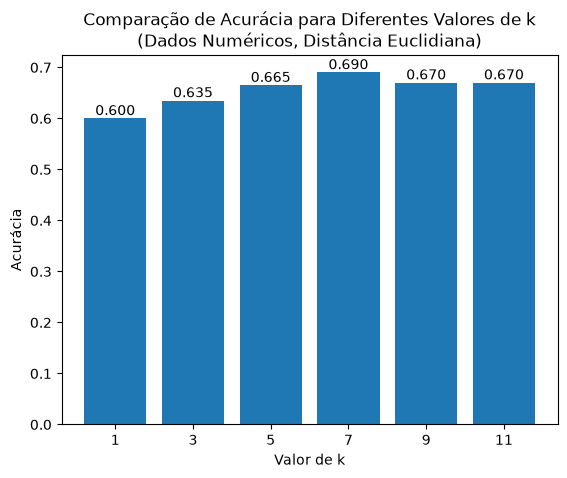

In [9]:
# =====================================================
# Comparação de diferentes valores de k (dados numéricos)
# =====================================================

# Nesta análise:
# - Usamos APENAS as variáveis numéricas (X_train_num e X_test_num)
# - Mantemos o MESMO conjunto para treinar e avaliar o modelo
# - Utilizamos distância euclidiana
# - Avaliamos desempenho via taxa de acerto (chamada de acurácia)
#
# O objetivo é observar como o hiperparâmetro k influencia a decisão do modelo.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Valores de k a serem comparados
valores_k = [1, 3, 5, 7, 9, 11]

# Lista para armazenar as acurácias
acuracias = []

for k in valores_k:

    # Criamos o modelo KNN com:
    # - n_neighbors = k
    # - metric = "euclidean" (distância euclidiana)
    modelo = KNeighborsClassifier(n_neighbors=k, metric="euclidean")

    # Treinamos o modelo usando apenas dados numéricos
    modelo.fit(X_train_num, y_train)

    # Realizamos a predição no conjunto de teste
    y_pred = modelo.predict(X_test_num)

    # Calculamos a acurácia
    acc = accuracy_score(y_test, y_pred)

    # Armazenamos o resultado
    acuracias.append(acc)

    print(f"k = {k} | Acurácia = {acc:.4f}")


# =====================================================
# Visualização dos resultados
# =====================================================

plt.figure()

bars = plt.bar([str(k) for k in valores_k], acuracias)

plt.xlabel("Valor de k")
plt.ylabel("Acurácia")
plt.title("Comparação de Acurácia para Diferentes Valores de k\n(Dados Numéricos, Distância Euclidiana)")

# Inserindo o valor da acurácia em cima de cada barra
for bar, acc in zip(bars, acuracias):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{acc:.3f}",
             ha='center',
             va='bottom')

plt.show()